In [1]:
from dilated_nns_nns import output_dir, default_config
from misc_utils import read_jsonl_to_df, keep_serializable, concat_columns, column_to
import seaborn as sns
import torch
from conv2d_circular import EquivariantConv2d, InvariantSpinCNNRegression
import numpy.typing as npt
import numpy as np


Running dilated_nns_xors.py


In [2]:
df = (
    read_jsonl_to_df(output_dir.glob("*/results.jsonl"))
    .fillna(keep_serializable(default_config))
)

In [3]:
df['lattice'].unique()

array(['square5x6', 'square5x5'], dtype=object)

In [25]:
df['target_mean'].mean()

0.474171560476808

In [26]:
df.pipe(column_to(str, "dilations")).query(
        "lattice == 'square5x5' and target_hidden_channels.astype('str') == '[64, 64, 64, 64]'"
    )

,eps_train,n_test,hidden_channels,dilations,epochs,runs,write_each_epoch,lr,batch_size,shuffle,...,lattice,test_accuracy,train_loss,epoch,start_timestamp,current_timestamp,run,task_id,n_train,target_mean
14000,0.0100,5000,"[32, 32, 32]","[3, 2, 1]",200,10,1,0.001,4192,True,...,square5x5,0.5162,0.690163,0,20240212_202731.506197,20240212_202733.477421,0,11,1721,0.499709
14001,0.0100,5000,"[32, 32, 32]","[3, 2, 1]",200,10,1,0.001,4192,True,...,square5x5,0.5166,0.686361,1,20240212_202731.506197,20240212_202733.558365,0,11,1721,0.499709
14002,0.0100,5000,"[32, 32, 32]","[3, 2, 1]",200,10,1,0.001,4192,True,...,square5x5,0.5204,0.682056,2,20240212_202731.506197,20240212_202733.567611,0,11,1721,0.499709
14003,0.0100,5000,"[32, 32, 32]","[3, 2, 1]",200,10,1,0.001,4192,True,...,square5x5,0.5416,0.676978,3,20240212_202731.506197,20240212_202733.578236,0,11,1721,0.499709
14004,0.0100,5000,"[32, 32, 32]","[3, 2, 1]",200,10,1,0.001,4192,True,...,square5x5,0.6196,0.670793,4,20240212_202731.506197,20240212_202733.587299,0,11,1721,0.499709
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61995,0.0001,5000,"[32, 32, 32]","[1, 2, 3]",200,10,1,0.001,4192,True,...,square5x5,0.7348,0.001602,195,20240212_202825.904539,20240212_202831.661985,9,10,17,0.470588
61996,0.0001,5000,"[32, 32, 32]","[1, 2, 3]",200,10,1,0.001,4192,True,...,square5x5,0.7344,0.001579,196,20240212_202825.904539,20240212_202831.671434,9,10,17,0.470588
61997,0.0001,5000,"[32, 32, 32]","[1, 2, 3]",200,10,1,0.001,4192,True,...,square5x5,0.7346,0.001557,197,20240212_202825.904539,20240212_202831.680841,9,10,17,0.470588
61998,0.0001,5000,"[32, 32, 32]","[1, 2, 3]",200,10,1,0.001,4192,True,...,square5x5,0.7346,0.001535,198,20240212_202825.904539,20240212_202831.690274,9,10,17,0.470588


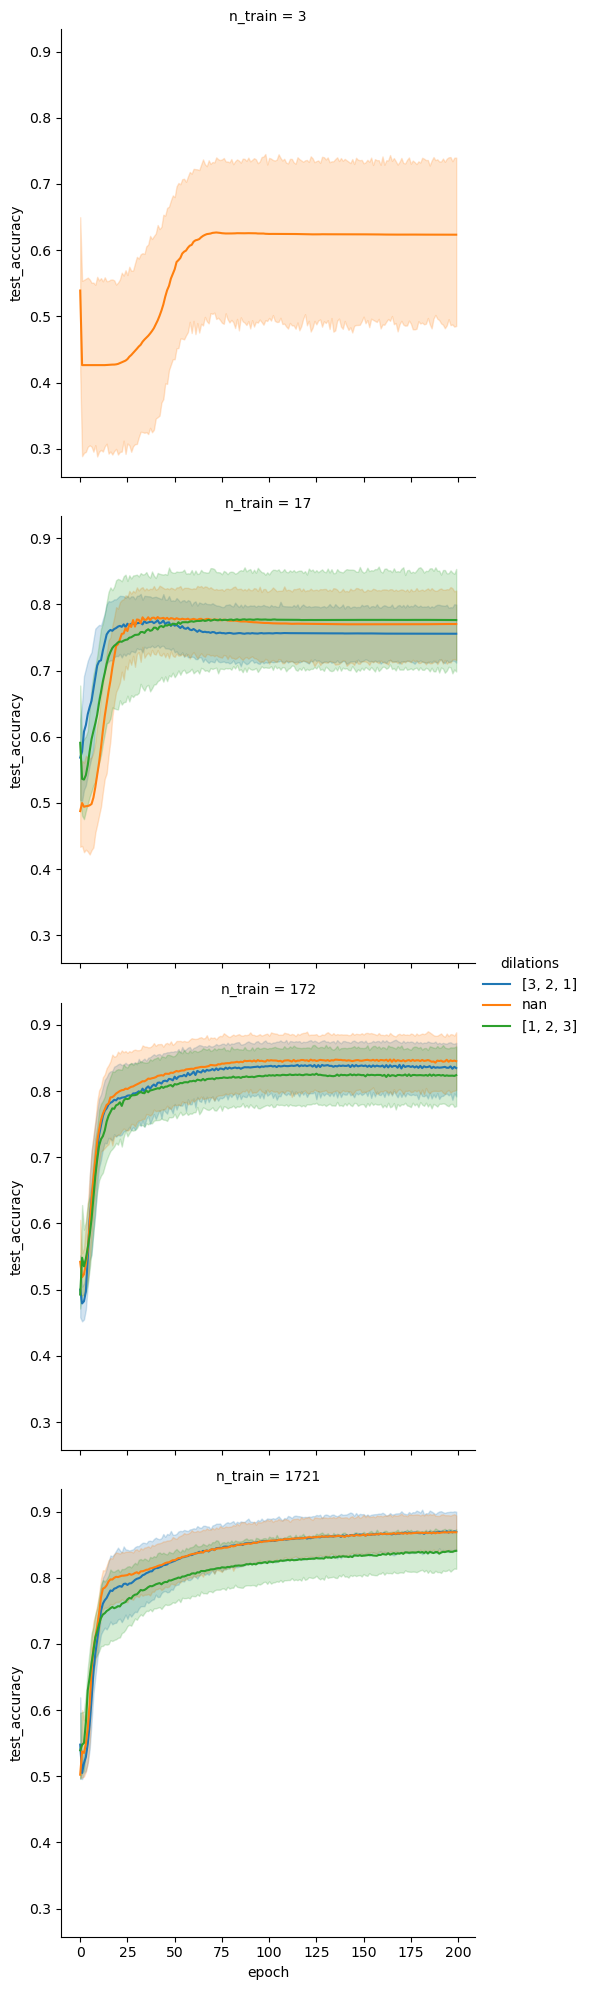

In [27]:
sns.relplot(
    df.pipe(column_to(str, "dilations")).query(
        "lattice == 'square5x5' and target_hidden_channels.astype('str') == '[64, 64, 64, 64]'"
    ),
    x="epoch",
    y="test_accuracy",
    hue="dilations",
    kind="line",
    row="n_train",
)

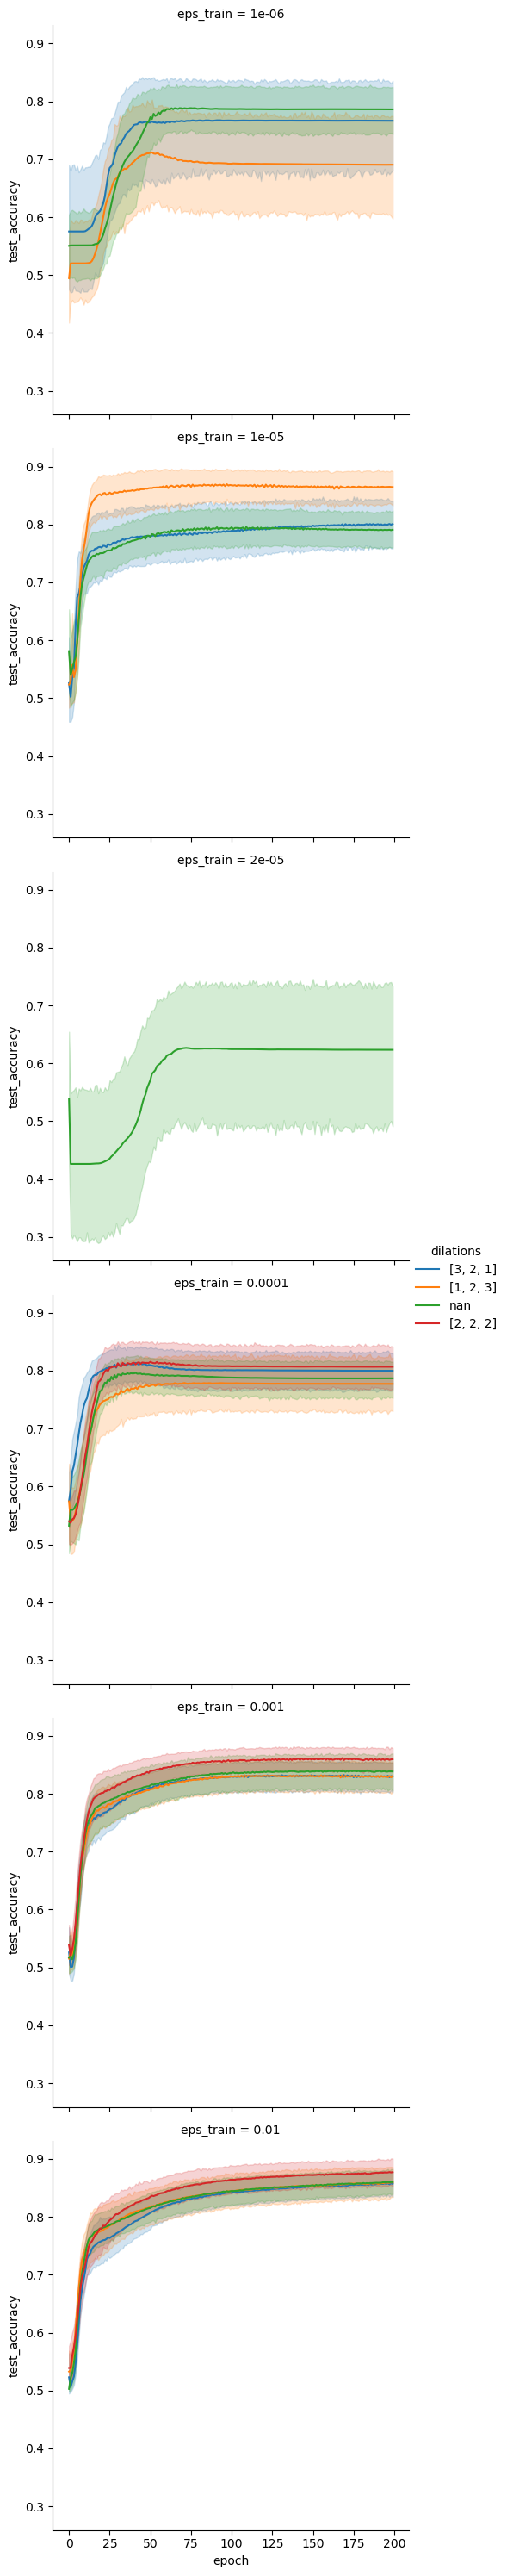

In [28]:
sns.relplot(
    df.pipe(column_to(str, "dilations")).query("kernel_size == 3"),
    x="epoch",
    y="test_accuracy",
    hue="dilations",
    kind="line",
    row="eps_train",
)